In [1]:
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
# Load the participant list CSV file
filename = 'participant_list_web.csv'
filepath = f'../input_data/{filename}'
# Confirm which columns are in the file
# This will help you understand the structure of your data
# just uncomment the next line to see the columns
# pd.read_csv(filepath).columns

# Specify the columns to keep from the CSV file
columns_to_keep = ['Collaboration', 'Rank']

# Read the data file
data = pd.read_csv(filepath, usecols=columns_to_keep)

color = "#00539B"  # This is Duke Royal blue and this "#012169"  # Duke navy blue


## Collaboration Counts

Here we count the occurrences of each collaboration mentioned in the 'Collaboration' column
in out data, and plot a bar chart of the results.

In [3]:
collab_counts = (
    data['Collaboration']
    .fillna('')
    .astype(str)
    .str.replace(';', ',', regex=False)  # normalize separators
    .str.split(',')
    .explode()
    .str.strip()
    .loc[lambda s: s != '']              # drop blanks
    .value_counts()
)

# Filter out responses that are not actual collaborations
# (e.g., "No" or "applied to become member")
collab_counts = collab_counts.drop(['No', '(applied to become LSST DESC member)'], errors='ignore')

# Uncomment to see the raw counts
# print(collab_counts)


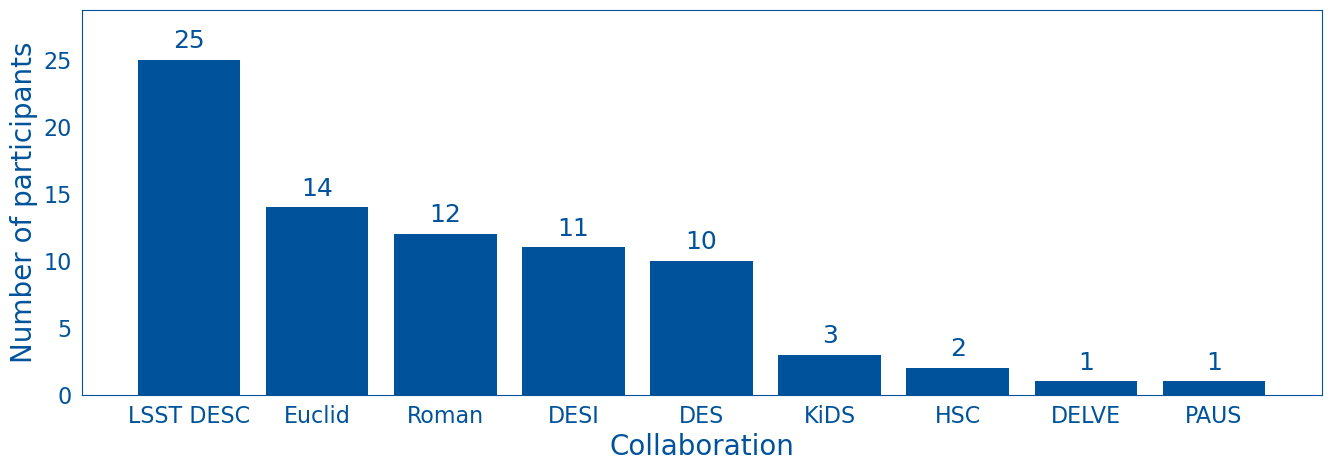

In [4]:
# sort counts in descending order
collab_counts = collab_counts.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 5))

bars = ax.bar(collab_counts.index, collab_counts.values, color=color)
ax.bar_label(bars, fmt="%d", padding=5, fontsize=18, color=color)

ax.set_xlabel("Collaboration", fontsize=20, color=color)
ax.set_ylabel("Number of participants", fontsize=20, color=color)
plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=16, color=color)
plt.setp(ax.get_yticklabels(), fontsize=16, color=color)
ax.tick_params(axis="both", colors=color)
ax.margins(y=0.15)  # 15% extra space above the tallest bar
ax.tick_params(left=False, bottom=False)

# remove the top and right spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(color)

plt.savefig("../assets/images/collaborations_bar.jpg",
            bbox_inches="tight", dpi=300, pad_inches=0.2)
plt.show()


## Rank Counts

Here we count the occurrences of each academic rank mentioned in the 'Rank' column
in our data, and plot a bar chart of the results.

In [5]:
# Count ranks
rank_counts = data['Rank'].fillna("Unknown").value_counts()

# Drop "Staff"
rank_counts = rank_counts.drop("Staff", errors="ignore")

# Sort (optional: by frequency or alphabetically)
rank_counts = rank_counts.sort_values(ascending=False)


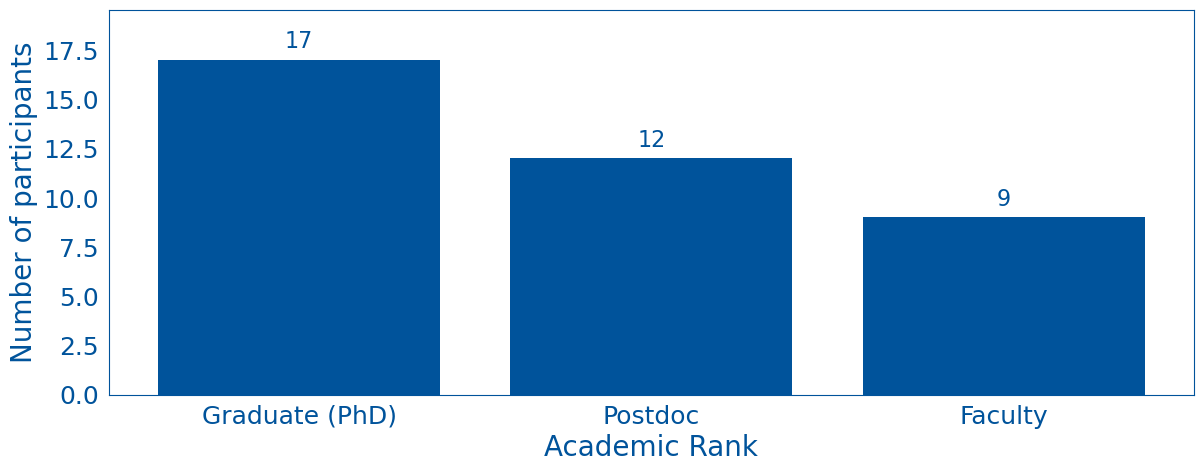

In [6]:
# Plot
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(rank_counts.index, rank_counts.values, color=color)

# Labels on bars
ax.bar_label(bars, fmt="%d", padding=5, fontsize=16, color=color)

# Axis labels
ax.set_xlabel("Academic Rank", fontsize=20, color=color)
ax.set_ylabel("Number of participants", fontsize=20, color=color)

# Tick labels
plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=18, color=color)
plt.setp(ax.get_yticklabels(), fontsize=18, color=color)

# Ticks
ax.tick_params(axis="both", colors=color, left=False, bottom=False)
ax.margins(y=0.15)

# Spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(color)

# Save
plt.savefig("../assets/images/rank_bar.jpg",
            bbox_inches="tight", dpi=300, pad_inches=0.2)
plt.show()
